# Preprocessing, clustering, and annotation workflow

This notebook introduces a basic exploration workflow on the PBMC3K dataset. PBMC3K is small enough to inspect quickly, but here it is used as a compact teaching example for the same on-disk workflow that scAtlasPy applies to much larger atlases.

By the end of this tutorial, you will be able to:

- create an Atlas database from an h5ad file;
- run quality control, filtering, normalization, HVG selection, and scaling;
- build a read index for downstream analysis;
- compute PCA, UMAP coordinates, and distilled Louvain clusters;
- visualize QC metrics, embeddings, and marker-gene expression;
- rank marker genes and add a simple manual cell-type annotation.

The central object is an `Atlas`: a persistent `.sasql` database that stores the expression matrix, cell and gene metadata, filtered analysis views, embeddings, cluster labels, marker statistics, and annotation results. The user-facing workflow stays close to established single-cell analysis in Python, while the data and intermediate results remain queryable on disk rather than being held entirely in memory.

This tutorial expects a PBMC3K h5ad file at `dataset/pbmc3k.h5ad`, creates a temporary atlas file at `tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql`, and then runs quality control, preprocessing, PCA, UMAP, clustering, marker-gene ranking, and cell-type annotation.

## 1. Setup

Run this notebook in a Python environment where scAtlasPy and its documentation dependencies are installed. See the installation guide for a complete setup.

Set `data_path` to the PBMC3K h5ad file you want to analyze. The tutorial writes its temporary `.sasql` database to `tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql`. Re-running the notebook will replace only this tutorial database; it will not modify the source h5ad file.

In [1]:
import os
from pathlib import Path
import warnings

import scatlaspy as sap

/home/hanxu/anaconda3/envs/scatlas-benchmarking/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# Keep tutorial outputs focused on the workflow rather than non-critical messages.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Hide progress bars in the rendered notebook.
sap.set_progress(False)

# Edit this path if your PBMC3K file is stored elsewhere.
os.chdir("/home/hanxu/scatlas-benchmarking")
data_path = Path("dataset/pbmc3k.h5ad")
db_path = Path("tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql")

if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path}. Please update data_path in this cell.")

# Create the output directory and remove any previous tutorial database.
db_path.parent.mkdir(parents=True, exist_ok=True)
if db_path.exists():
    db_path.unlink()
wal_path = db_path.with_name(db_path.name + ".wal")
if wal_path.exists():
    wal_path.unlink()

print(f"data: {data_path}")
print(f"database: {db_path}")

data: dataset/pbmc3k.h5ad
database: tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql


## 2. Create an Atlas database

`load_h5ad()` imports the expression matrix and metadata into a DuckDB-backed Atlas database. The database is a normal file with the `.sasql` suffix, so it can be closed, reopened, queried, and used as the persistent record of the analysis.

This example uses `load_type="random"`, matching the randomized block-import path used for larger datasets. For small data where preserving the exact h5ad cell order is important, `load_type="order"` is also available.

scAtlasPy automatically detects whether the source matrix contains count-scale or log-transformed values and stores expression data on the count scale in the Atlas. Normalization and log transformation should be performed after import using the `sap.pp` preprocessing functions.

```{note}
`db_memory_limit` controls the memory available to DuckDB for database queries,
imports, and intermediate database operations. It is not a global memory limit
for all of scAtlasPy, Python, NumPy, pandas, or plotting code. A more permissive
DuckDB memory limit can reduce repeated disk access and improve performance when
adequate system memory is available. The default requested limit is
`db_memory_limit="10G"`, capped at 60% of detected system physical memory.
Passing `db_memory_limit=None` explicitly uses that 60% system-memory cap
without an additional user-specified cap.
```


In [3]:
atlas = sap.Atlas(db_path)
atlas.load_h5ad(data_path, load_type="random")

print(atlas)

file_name       : /high_speed_data/hanxu/scatlas-benchmarking/tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql
db_memory_limit : 10GB
tables          : 4
table names     : X_HyS_data, X_HyS_indptr, obs, var
n_cells         : 2,700
n_genes         : 32,738


## 3. Quality control

The QC functions compute standard per-cell and per-gene summaries inside the Atlas database. `filter_cells()` and `filter_genes()` mark cells and genes that pass the selected thresholds; they do not physically delete rows from the atlas. This makes threshold changes cheap because the original imported data remain available.

The plots below give the same checks a user would perform in an in-memory Scanpy workflow: highly expressed genes, distributions of QC metrics, and relationships among counts, detected genes, and mitochondrial content.

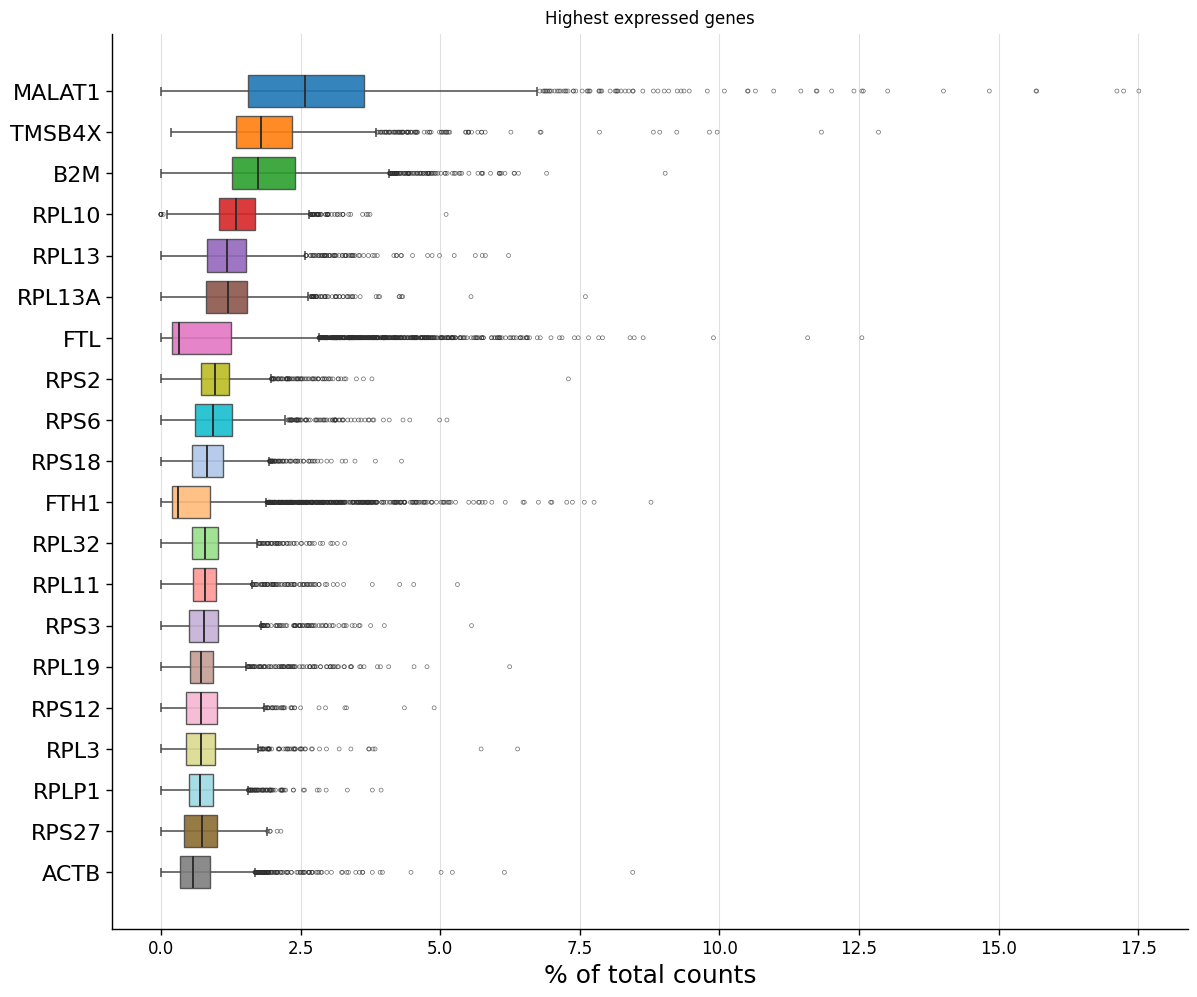

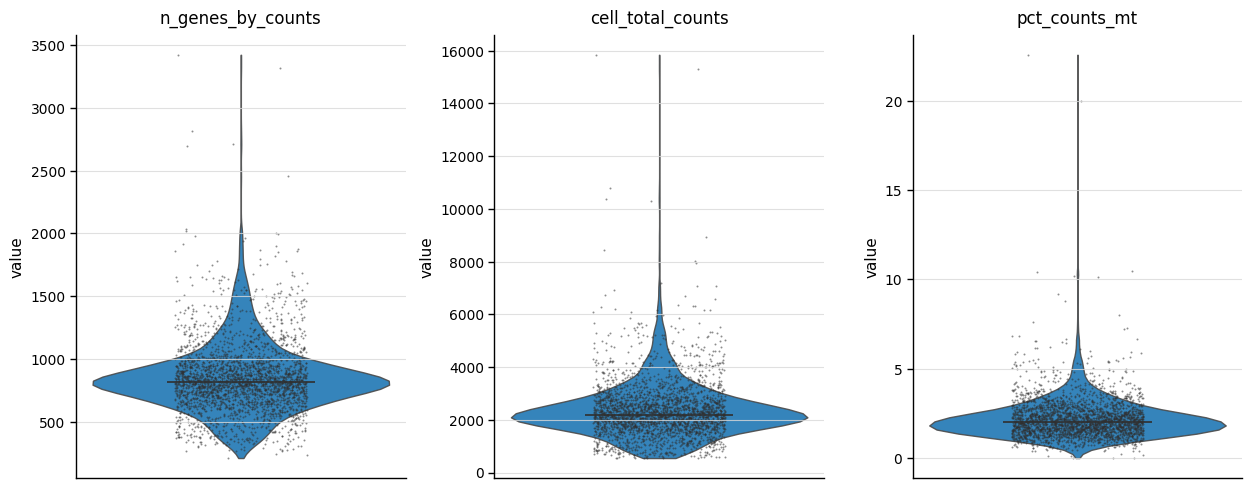

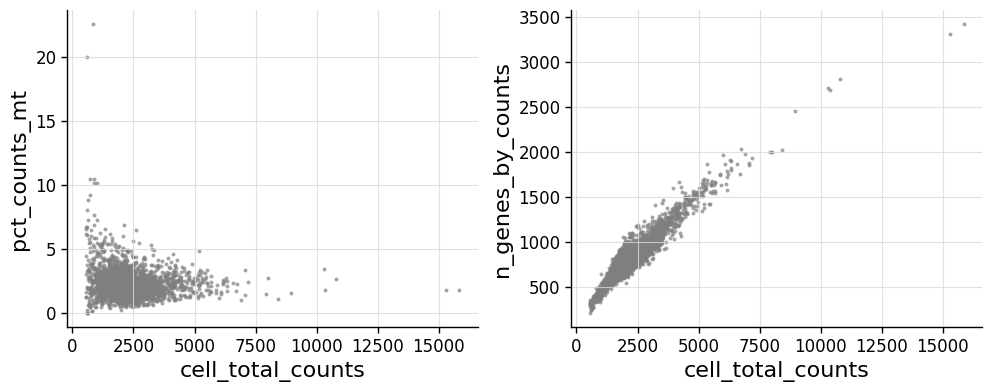

In [4]:
# Inspect whether a few genes dominate the count distribution.
sap.pl.highest_expr_genes(atlas, n_top=20)

# Apply basic cell and gene filters before downstream analysis.
sap.pp.filter_cells(atlas, min_genes=200)
sap.pp.filter_genes(atlas, min_cells=3)

# Compute and visualize standard per-cell QC metrics.
sap.pp.calculate_qc_metrics(atlas)
sap.pl.violin_qc_metrics(atlas)
sap.pl.scatter_qc_metrics(atlas)

## 4. Normalize and log-transform counts

scAtlasPy stores imported counts in `data_count` and materializes transformed representations in derived expression tables. In this workflow, library-size-normalized, log1p-transformed values are written as `data_log1p`.

In [5]:
sap.pp.normalize_and_log1p(atlas, target_sum=10_000)

## 5. Select highly variable genes

`highly_variable_genes()` writes a Boolean marker to the `var` table. These genes define a compact feature set for PCA and clustering.

```{note}
Use the same `flavor` when plotting highly variable genes as you used when computing them. For example, after `flavor="seurat"`, call `sap.pl.highly_variable_genes(..., flavor="seurat")`.
```

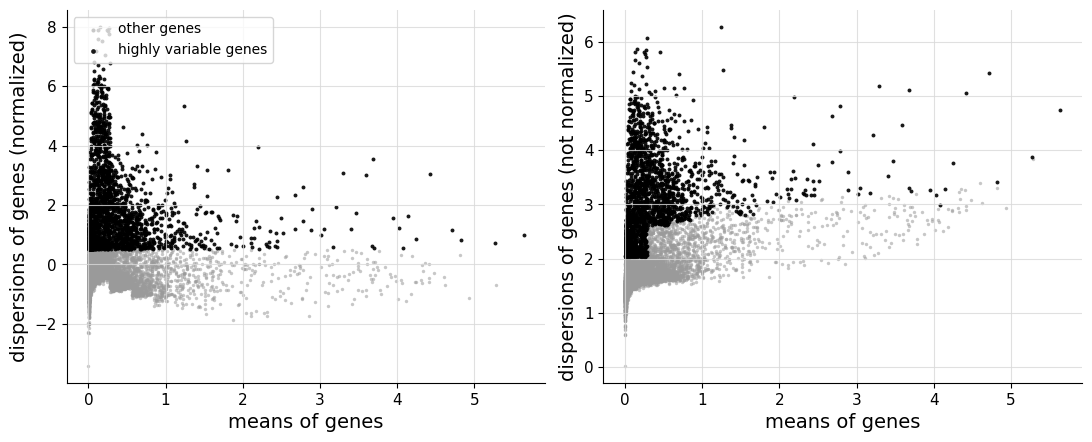

In [6]:
sap.pp.highly_variable_genes(atlas, flavor="seurat")
sap.pl.highly_variable_genes(atlas, flavor="seurat")

## 6. Scale data

Scaling writes centered or standardized values to `data_scale`, which is commonly used before PCA and clustering. Use `mode="center_only"` if you want PCA to preserve gene-level expression-strength differences, or the default `mode="center_and_scale"` if you want selected genes on comparable expression scales.

```{tip}
scAtlasPy stores z-scored data with the same highly efficient HyS sparse-compressed layout used for expression matrices. Scaling therefore does not cause a storage blow-up from turning many implicit zeros into explicit nonzero values.
```

In [7]:
sap.pp.scale(atlas)

## 7. Build the read index

`build_read_index()` combines cell filters, gene filters, the HVG flag, and the selected expression field into a compact analysis view for efficient traversal. Downstream routines can then quickly iterate over this view in minibatches instead of materializing the complete matrix in memory.

The `use_data` setting controls which expression field is read when a routine traverses the dataset to fit a model. This tutorial uses `data_scale`, which is required by `sap.tl.pca()` because PCA expects a centered read index. For non-PCA model-training routines, you can build the read index from `data_log1p` instead if that is the representation you want those routines to iterate over.

In [8]:
atlas.build_read_index(
    use_hvg=True,
    use_data="data_scale"
)

## 8. PCA

PCA reads the matrix defined by the current read index. In this workflow, the read index was built from scaled HVGs. The same PCA API can be applied to another analysis view if you first rebuild the read index with a different `use_data` or feature selection.

scAtlasPy uses a streaming randomized PCA backend by default. The matrix is scanned in dense minibatches, so PCA can be fitted and projected without materializing the full cell-by-gene matrix in memory.

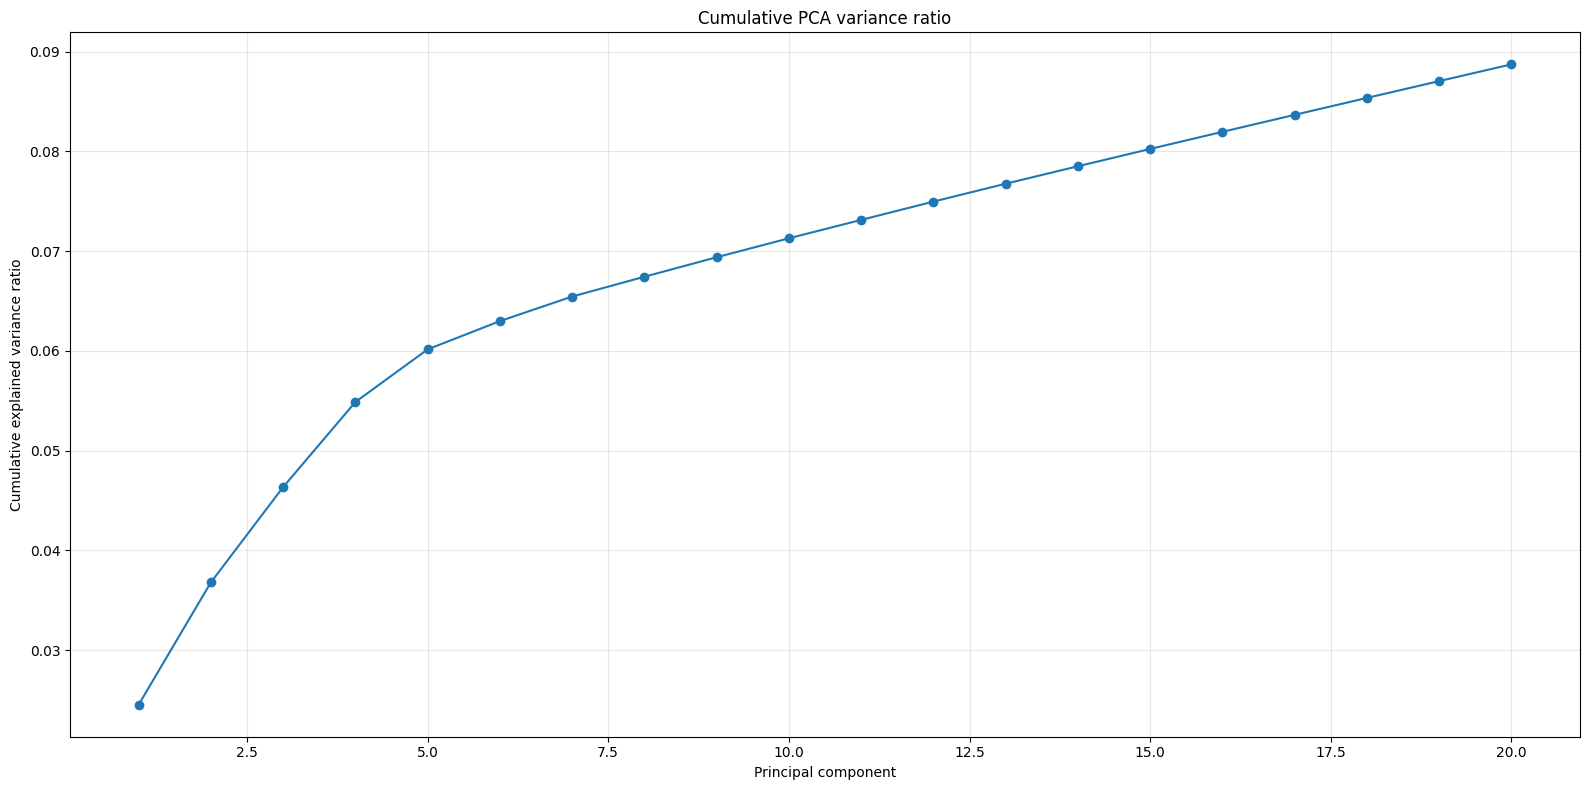

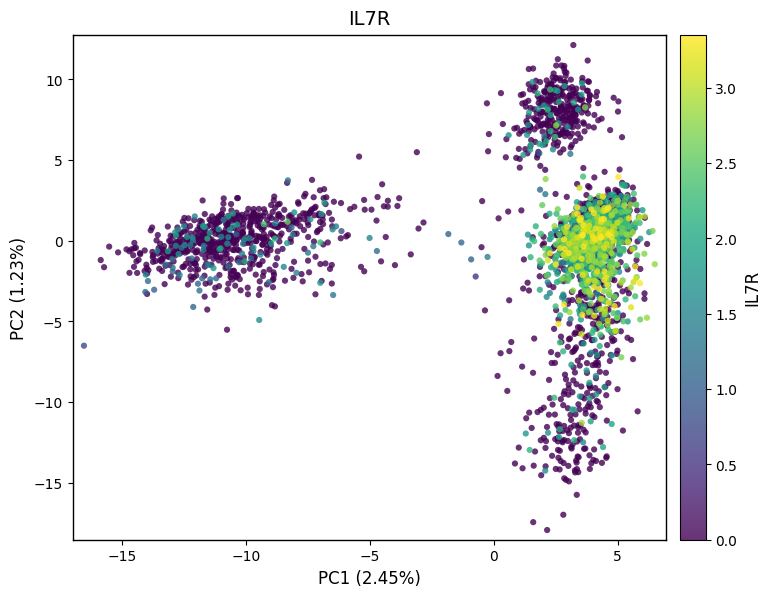

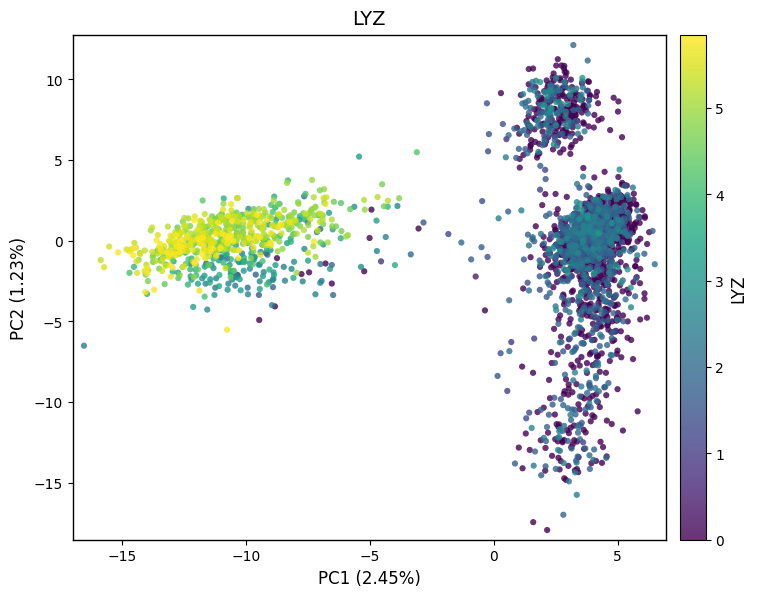

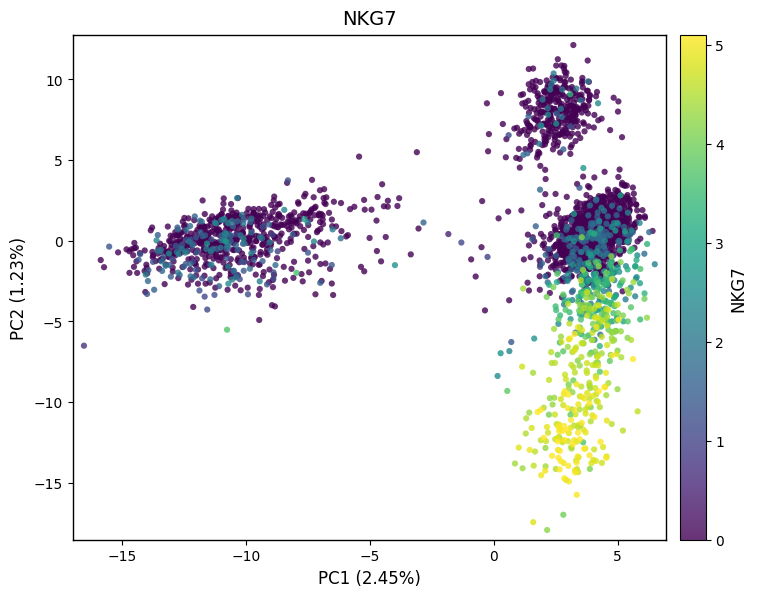

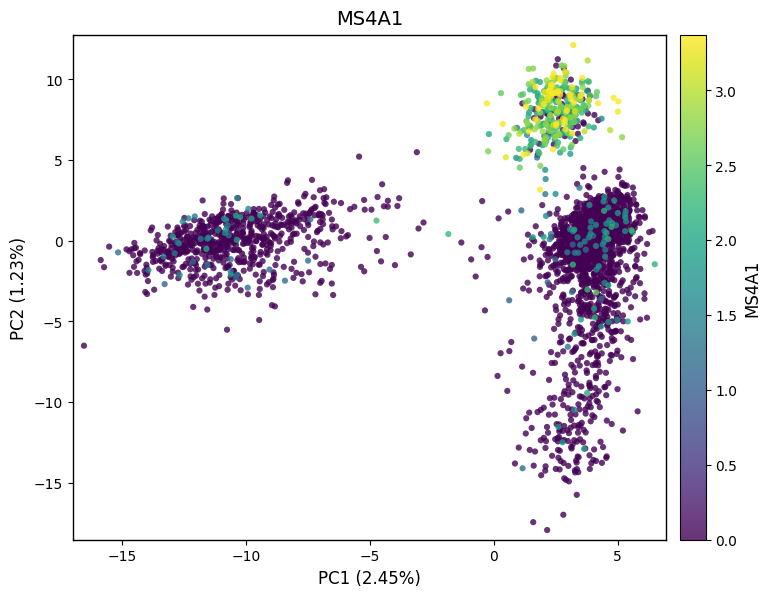

In [9]:
sap.tl.pca(atlas, n_components=30)
sap.pl.pca_variance_ratio_cumsum(atlas, n_pcs=20)

# Color PC1/PC2 by canonical PBMC marker genes.
for marker_gene in ["IL7R", "LYZ", "NKG7", "MS4A1"]:
    sap.pl.pca(
        atlas,
        color=marker_gene,
        x_pc=0,
        y_pc=1,
        use_data="data_log1p",
        point_size=20,
        figsize=(8, 6),
    )

```{note}
`fit_batch_size` controls how many cells are included in each dense minibatch during PCA fitting. `transform_batch_size` controls the batch size used when writing PCA coordinates. For the randomized streaming PCA backend, `oversample` and `n_iter` control the randomized subspace accuracy. Larger values improve agreement with exact PCA but require more computation.
```


## 9. UMAP and Distilled Louvain

UMAP is computed from the PCA coordinates stored in `obsm_X_pca` and written back to the Atlas database as `obsm_X_umap`. scAtlasPy uses a PyTorch teacher-student UMAP workflow: a UMAP teacher is fitted on PCA coordinates, and a neural network predicts coordinates for all cells in batches.

Distilled Louvain fits a graph-clustering teacher in PCA space, trains a PyTorch student, and writes full-Atlas cluster labels back to `obs`.

UMAP(min_dist=0.3, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Aug  3 17:19:19 2026 Construct fuzzy simplicial set


/home/hanxu/anaconda3/envs/scatlas-benchmarking/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


Mon Aug  3 17:19:23 2026 Finding Nearest Neighbors
Mon Aug  3 17:19:28 2026 Finished Nearest Neighbor Search
Mon Aug  3 17:19:33 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Aug  3 17:19:38 2026 Finished embedding


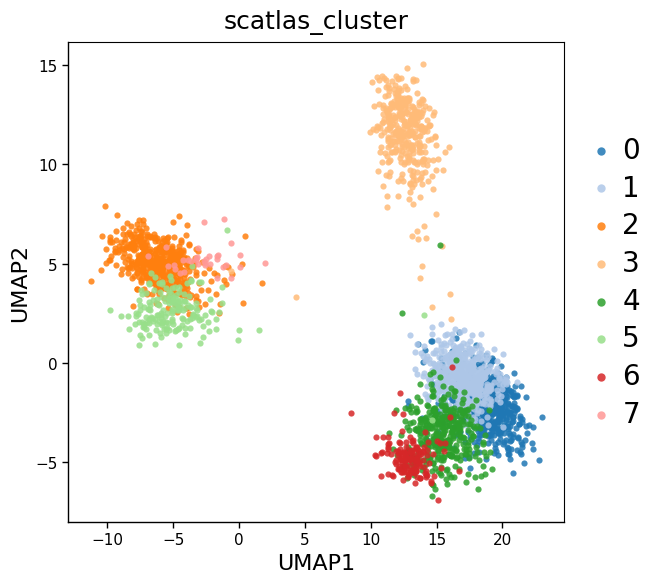

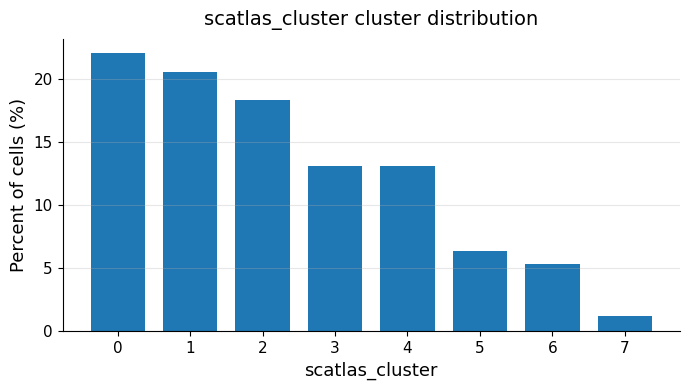

In [10]:
sap.tl.umap(
    atlas,
    n_pcs=20,
    n_neighbors=30,
    min_dist=0.3,
    torch_epochs=20,
    eval_sample_n=1000,
)

sap.tl.graph_clustering(
    atlas,
    mode="distilled_louvain",
    n_pcs=20,
    n_neighbors=30,
    add_obs_col="scatlas_cluster",
)

sap.pl.umap(
    atlas,
    color="scatlas_cluster",
    point_size=20,
    figsize=(8, 6),
)

sap.pl.cluster_size(atlas, use_obs_col="scatlas_cluster")

## 10. Visualize Distilled Louvain labels

Plotting functions read the stored PCA and UMAP embeddings and can color cells by cluster labels or other metadata columns.

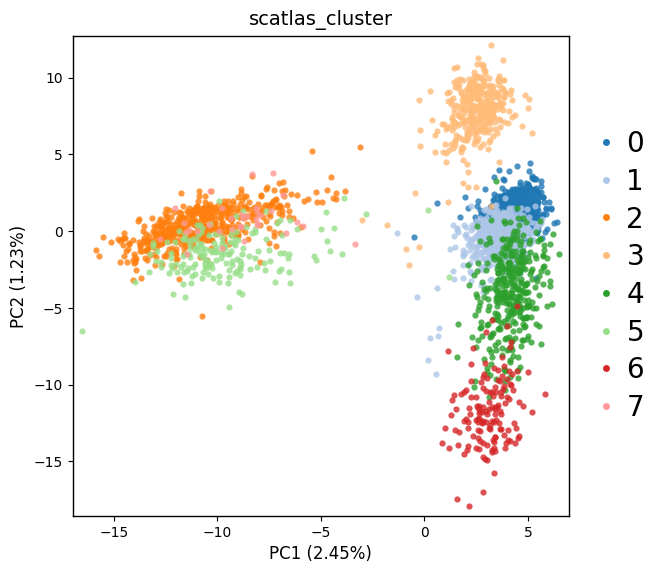

In [11]:
sap.pl.pca(
    atlas,
    color="scatlas_cluster",
    x_pc=0,
    y_pc=1,
    point_size=20,
    figsize=(8, 6),
)

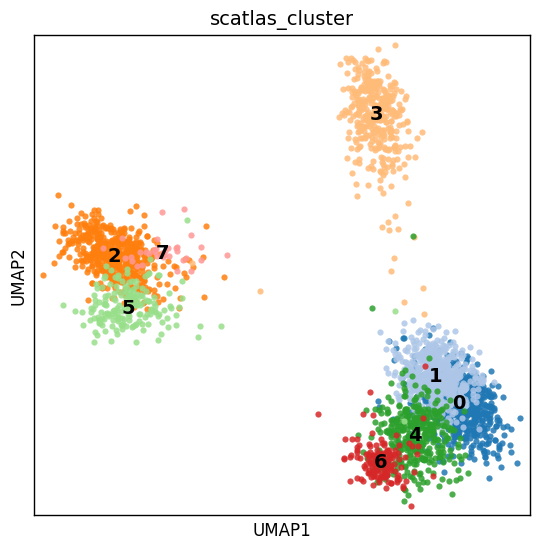

In [12]:
sap.pl.umap(
    atlas,
    color="scatlas_cluster",
    legend_loc="on_data",
    sample_n=None,
    point_size=20,
    figsize=(8, 6),
)

## 11. Visualize marker-gene expression

Marker-gene UMAPs show how expression fields can be selected explicitly with `use_data`. Here, `data_log1p` is used for interpretable marker expression.

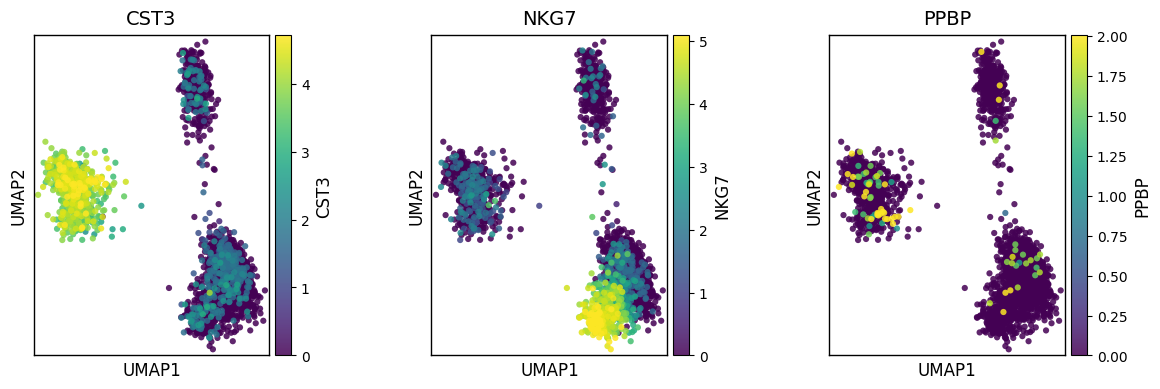

In [13]:
sap.pl.umap(
    atlas,
    color=["CST3", "NKG7", "PPBP"],
    use_data="data_log1p",
    sample_n=None,
    point_size=20,
    figsize=(12, 4),
)

## 12. Rank marker genes

`rank_genes_groups()` computes marker statistics for each cluster and stores the result in the Atlas database. The returned table can be inspected directly, plotted with scAtlasPy, or used to support manual annotation.

Distilled Louvain labels are an unsupervised grouping, not cell types. Marker ranking provides the evidence needed to interpret those groups biologically.

In [14]:
rank_result = sap.tl.rank_genes_groups(
    atlas,
    groupby="scatlas_cluster",
    use_data="data_log1p",
    add_table="rank_genes_groups",
)
rank_result.head()

,group,reference,rank,atlas_gene_id,names,scores,logfoldchanges,pvals,pvals_adj,mean_in,mean_ref,pct_nz_in,pct_nz_ref,n_in,n_ref,method
0,0,rest,0,1989,RPS27,28.642182,0.888241,4.471126e-150,1.829697e-146,4.610731,4.003475,0.998319,0.991924,595,2105,t-test
1,0,rest,1,11447,RPS12,28.533267,0.882218,2.113375e-149,7.687520e-146,4.635982,4.032618,1.000000,0.990499,595,2105,t-test
2,0,rest,2,19154,MALAT1,26.250987,0.889074,6.019459e-126,1.642209e-122,5.912636,5.298679,1.000000,0.999525,595,2105,t-test
3,0,rest,3,19827,RPS25,26.138644,0.975257,2.738060e-127,8.148965e-124,3.896709,3.240141,0.996639,0.974347,595,2105,t-test
4,0,rest,4,5521,RPL32,25.817802,0.731624,1.435612e-122,3.133270e-119,4.683814,4.182778,0.998319,0.994774,595,2105,t-test


A volcano plot summarizes marker-gene direction and significance for one cluster against the reference group. Here, cluster `0` is shown as a compact example.

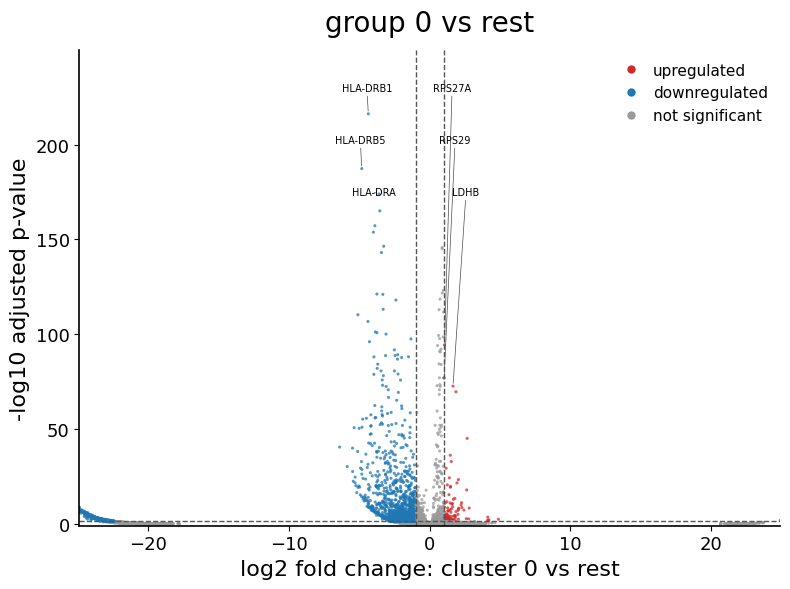

In [15]:
sap.pl.rank_genes_groups_volcano(atlas, group="0", top_n=6, figsize=(8, 6))

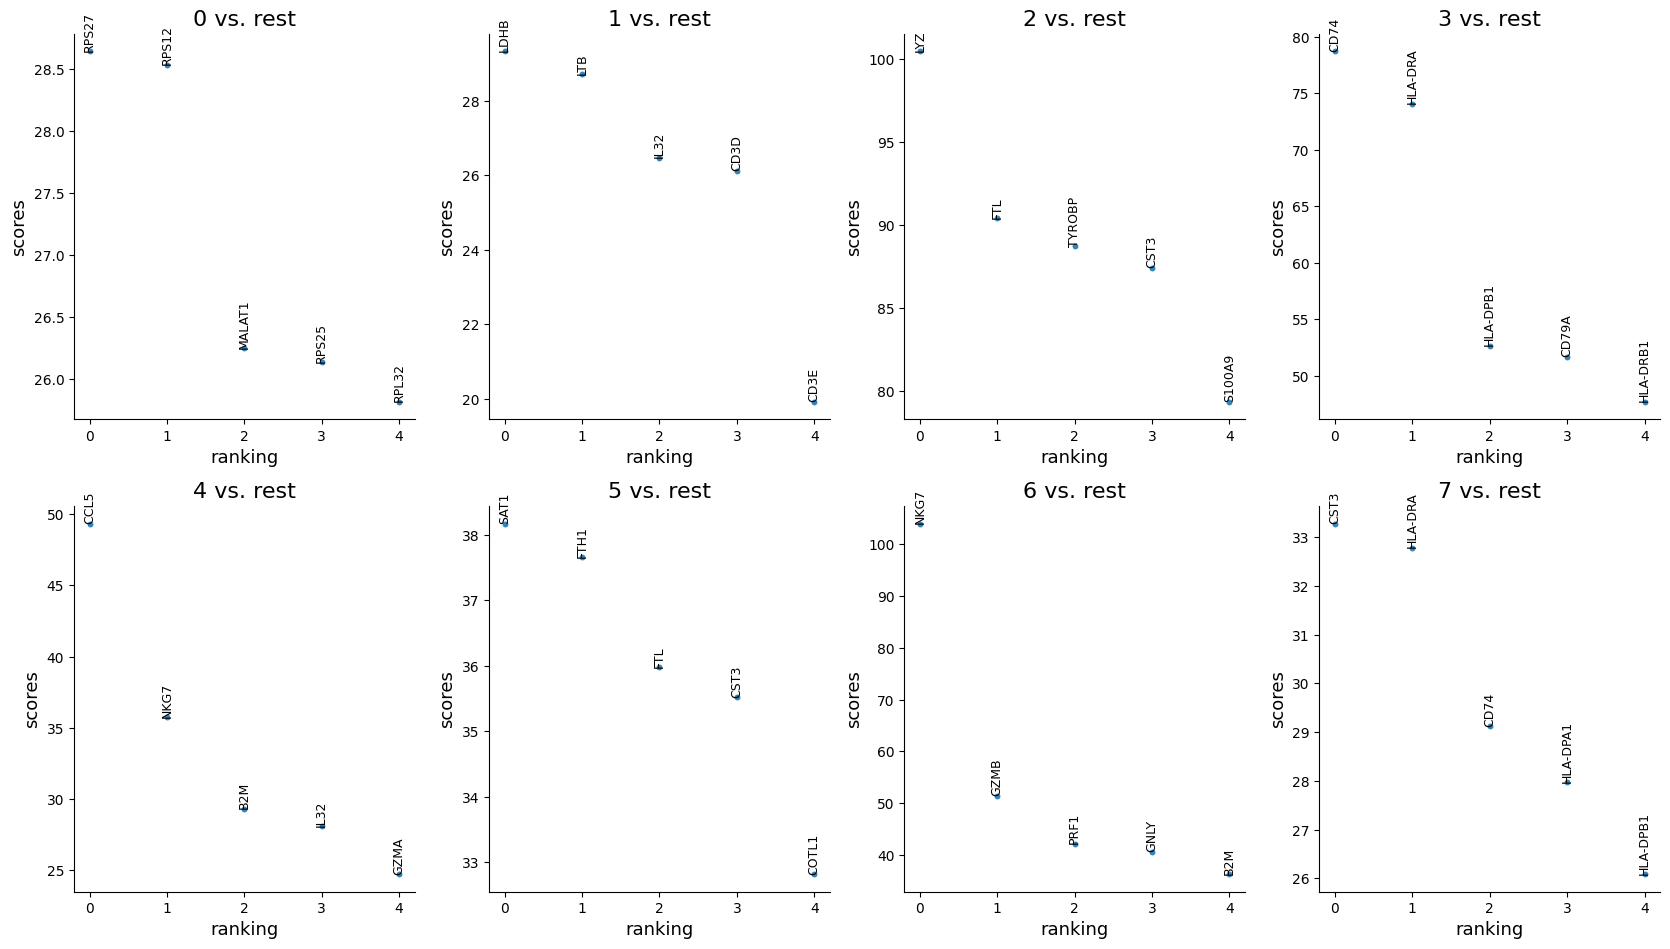

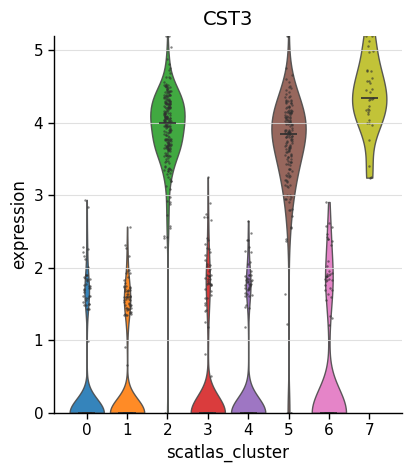

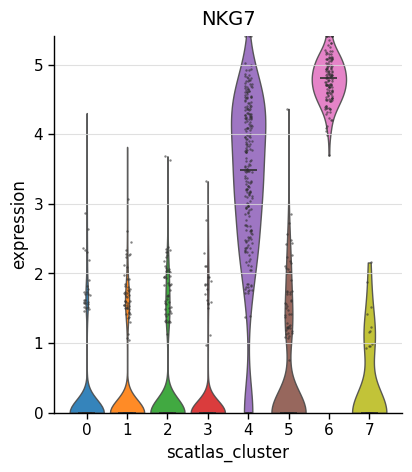

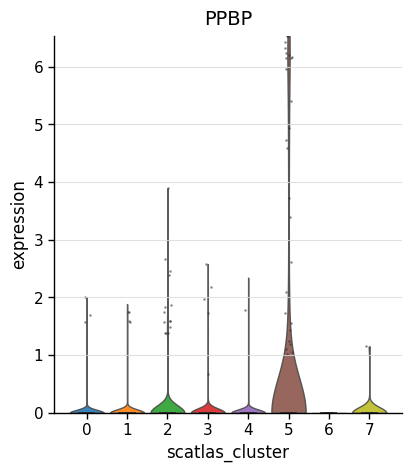

In [16]:
sap.pl.rank_genes_groups(atlas, n_genes=5)
for gene in ["CST3", "NKG7", "PPBP"]:
    sap.pl.violin(atlas, genes=gene, groupby="scatlas_cluster")

## 13. Manual annotation

The mapping below assigns example cell-type labels to selected distilled Louvain clusters after marker inspection. Clusters that are not included in the mapping are written as `Unknown`. In a real analysis, this step should be adjusted using the marker-gene rankings, UMAP expression patterns, sample metadata, and domain knowledge.

`manual_annotate_clusters()` writes the labels to a new `obs` column, here `cell_type_manual`, and records the mapping in a separate annotation table so that the interpretation is preserved with the atlas.

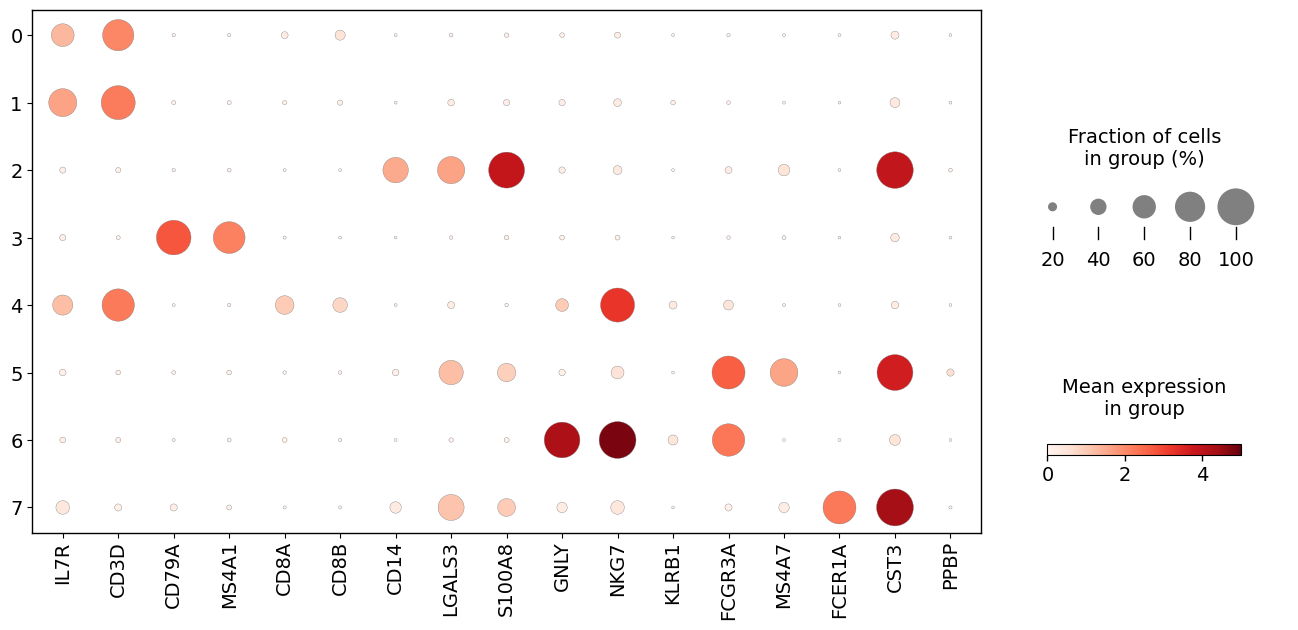

In [17]:
marker_genes = [
    "IL7R",
    "CD3D",
    "CD79A",
    "MS4A1",
    "CD8A",
    "CD8B",
    "CD14",
    "LGALS3",
    "S100A8",
    "GNLY",
    "NKG7",
    "KLRB1",
    "FCGR3A",
    "MS4A7",
    "FCER1A",
    "CST3",
    "PPBP",
]

dotplot_stats = sap.pl.dotplot(
    atlas,
    genes=marker_genes,
    groupby="scatlas_cluster",
    use_data="data_log1p",
)

In [18]:
mapping = {
    "0": "CD4 T",
    "1": "CD4 T",
    "2": "CD14+ Monocytes",
    "3": "B",
    "4": "CD8 T",
    "5": "FCGR3A+ Monocytes",
    "6": "NK",
    "7": "Dendritic",
}

summary = sap.tl.manual_annotate_clusters(
    atlas,
    cluster_to_cell_type=mapping,
    groupby="scatlas_cluster",
    obs_col="cell_type_manual",
    table_name="manual_cluster_annotation",
    unknown_label="Unknown",
)

summary

,cluster_id,cell_type,n_cells
0,0,CD4 T,595
1,1,CD4 T,554
2,2,CD14+ Monocytes,495
3,3,B,354
4,4,CD8 T,353
5,5,FCGR3A+ Monocytes,172
6,6,NK,143
7,7,Dendritic,34


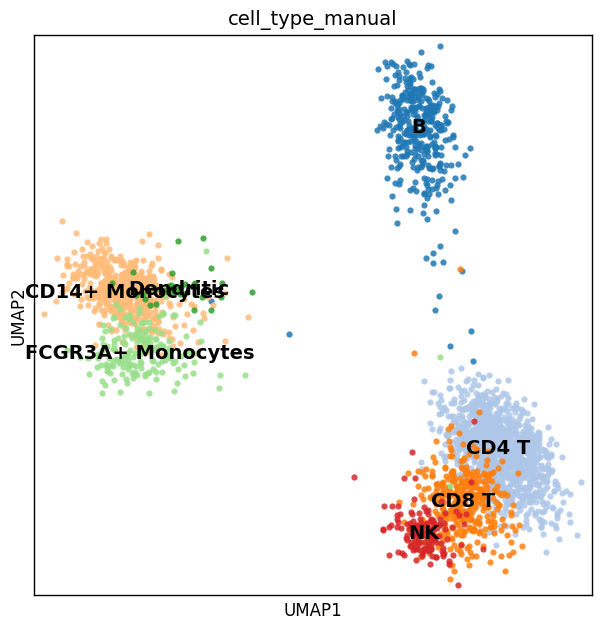

In [19]:
sap.pl.umap(
    atlas,
    color="cell_type_manual",
    legend_loc="on_data",
    sample_n=None,
    point_size=20,
    figsize=(9, 7),
)

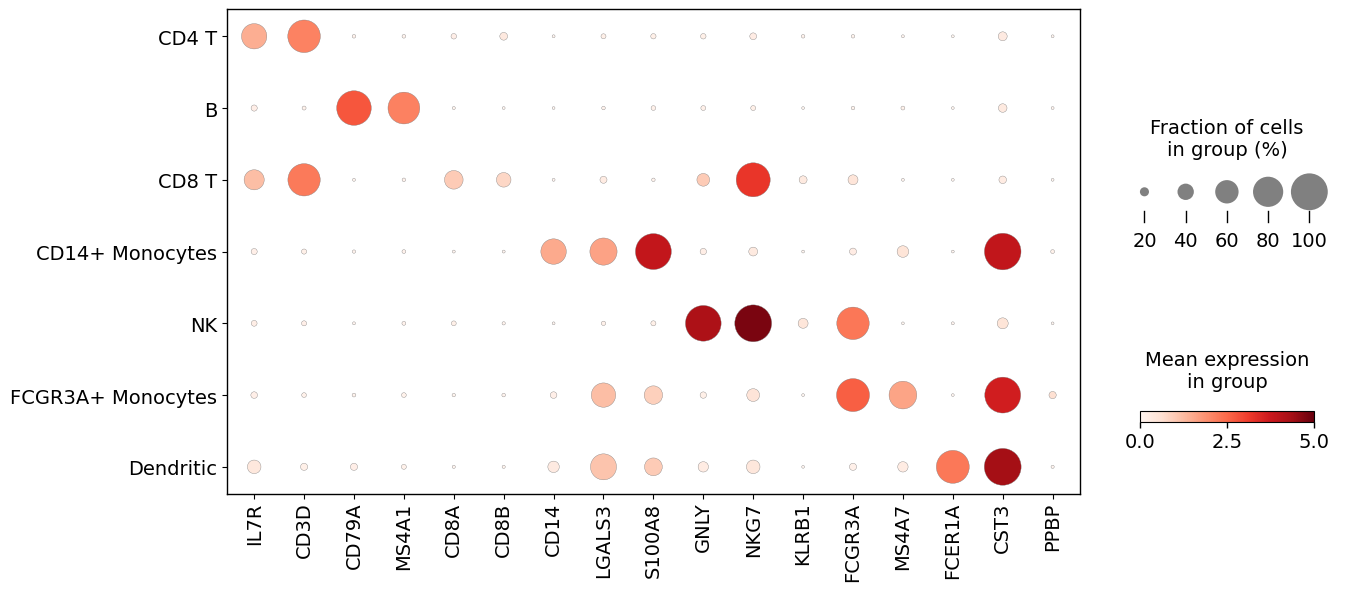

In [20]:
dotplot_stats = sap.pl.dotplot(
    atlas,
    genes=marker_genes,
    groupby="cell_type_manual",
    use_data="data_log1p",
    order=[
        "CD4 T",
        "B",
        "CD8 T",
        "CD14+ Monocytes",
        "NK",
        "NKT",
        "FCGR3A+ Monocytes",
        "Dendritic",
    ],
)

## 14. Close the database

Close the Atlas connection when the workflow is complete. The `.sasql` file remains on disk and can be reopened later for additional analysis, SQL queries, export to AnnData, or method development.

In [21]:
print(atlas.describe())
atlas.close()

file_name       : /high_speed_data/hanxu/scatlas-benchmarking/tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql
db_memory_limit : 10GB
tables          : 23
table names     : X_HyS_data, X_HyS_data_data_log1p, X_HyS_data_data_scale, X_HyS_data_filtered, X_HyS_indptr, X_HyS_indptr_filtered, __append_df, _pca_plot_sample_ids, atlas_expression_transform_meta, atlas_read_index_meta, manual_cluster_annotation, obs, obs_cluster_distilled_louvain, obsm_X_pca, obsm_X_umap, rank_genes_groups, uns_graph_clustering_eval, uns_graph_clustering_params, uns_pca_stats, uns_umap_eval, uns_umap_params, var, varm_PCs
n_cells         : 2,700
n_genes         : 32,738
None
